1. Data snapshots- 1=Disease, 0=Healthy

In [24]:
import numpy as np
import pandas as pd

scaled_filled1 = pd.read_csv("infection_matrix_with_nulls_experimental_300x300_1.csv", header=None)
scaled_filled2 = pd.read_csv("infection_matrix_with_nulls_experimental_300x300_2.csv", header=None)
scaled_filled3 = pd.read_csv("infection_matrix_with_nulls_experimental_300x300_3.csv", header=None)
scaled_filled4 = pd.read_csv("infection_matrix_with_nulls_experimental_300x300_4.csv", header=None)
scaled_filled5 = pd.read_csv("infection_matrix_with_nulls_experimental_300x300_5.csv", header=None)

x1 =  np.array(
    scaled_filled1
)

x2 =  np.array(
    scaled_filled2
)

x3 =  np.array(
    scaled_filled3
)

x4 =  np.array(
    scaled_filled4
)

x5 =  np.array(
    scaled_filled5
)

print("Collected Data:")
print("Visit 1:\n", x1)
print(x1.shape)
print("Visit 2:\n", x2)
print("Visit 3:\n", x3)
print("Visit 4:\n", x4)
print("Visit 5:\n", x5)

Collected Data:
Visit 1:
 [[0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 ...
 [2.32 2.19 1.84 ... 0.   0.   0.  ]
 [0.86 0.81 0.68 ... 0.   0.   0.  ]
 [0.28 0.26 0.22 ... 0.   0.   0.  ]]
(300, 300)
Visit 2:
 [[0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 ...
 [2.32 2.19 1.84 ... 0.   0.   0.  ]
 [0.86 0.81 0.68 ... 0.   0.   0.  ]
 [0.28 0.26 0.22 ... 0.   0.   0.  ]]
Visit 3:
 [[0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 ...
 [2.32 2.19 1.84 ... 0.   0.   0.  ]
 [0.86 0.81 0.68 ... 0.   0.   0.  ]
 [0.28 0.26 0.22 ... 0.   0.   0.  ]]
Visit 4:
 [[0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 ...
 [2.32 2.19 1.84 ... 0.   0.   0.  ]
 [0.86 0.81 0.68 ... 0.   0.   0.  ]
 [0.28 0.26 0.22 ... 0.   0.   0.  ]]
Visit 5:
 [[0.   0.  

2. Flatten the data to apply DMD

In [25]:
x1_vec = x1.flatten()
x2_vec = x2.flatten()
x3_vec = x3.flatten()
x4_vec = x4.flatten()
x5_vec = x5.flatten()

print("Flattened Data: ")
print("Visit 1:\n", x1_vec)
print(x1_vec.shape)
print("Visit 2:\n", x2_vec)
print("Visit 3:\n", x3_vec)
print("Visit 4:\n", x4_vec)
print("Visit 5:\n", x5_vec)


Flattened Data: 
Visit 1:
 [0. 0. 0. ... 0. 0. 0.]
(90000,)
Visit 2:
 [0. 0. 0. ... 0. 0. 0.]
Visit 3:
 [0. 0. 0. ... 0. 0. 0.]
Visit 4:
 [0. 0. 0. ... 0. 0. 0.]
Visit 5:
 [0. 0. 0. ... 0. 0. 0.]


3. Create X1 and X2

In [26]:
X1 = np.column_stack((x1_vec, x2_vec, x3_vec, x4_vec))  
X2 = np.column_stack((x2_vec, x3_vec, x4_vec, x5_vec))

print("X1 Matrix:\n", X1)
print("X2 Matrix:\n", X2)

X1 Matrix:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 ...
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
X2 Matrix:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 ...
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


4. Compute SVD of X1

In [27]:
from sklearn.utils.extmath import randomized_svd
import numpy as np


# Compute SVD
X1 = np.nan_to_num(X1, nan=0.0, posinf=0.0, neginf=0.0)

X2 = np.nan_to_num(X2, nan=0.0, posinf=0.0, neginf=0.0)

U, sigma, Vt = randomized_svd(X1, n_components=100)


# Convert sigma (1D array) to diagonal matrix
Sigma = np.zeros((U.shape[1], Vt.shape[0]))
np.fill_diagonal(Sigma, sigma)

# Print results
np.set_printoptions(precision=3, suppress=True)

print("U Matrix:")
print(U)

print("\nSigma Matrix:")
print(Sigma)

print("\nV* (V transpose) Matrix:")
print(Vt)

# ✅ Verify reconstruction
X1_reconstructed = U @ Sigma @ Vt

print("\nReconstructed X1 Matrix:")
print(np.round(X1_reconstructed, 10))

# Check if approximately equal
print("\nIs reconstruction close to original? ->", np.allclose(X1, X1_reconstructed))



U Matrix:
[[-0.  0. -0.  0.]
 [ 0. -0.  0.  0.]
 [-0. -0.  0.  0.]
 ...
 [ 0.  0. -0.  0.]
 [ 0.  0. -0.  0.]
 [ 0.  0. -0.  0.]]

Sigma Matrix:
[[15951.4       0.        0.        0.   ]
 [    0.     3504.073     0.        0.   ]
 [    0.        0.     2019.058     0.   ]
 [    0.        0.        0.     1109.702]]

V* (V transpose) Matrix:
[[ 0.187  0.417  0.559  0.692]
 [ 0.771  0.43   0.002 -0.469]
 [ 0.469 -0.243 -0.651  0.545]
 [ 0.387 -0.763  0.514 -0.06 ]]

Reconstructed X1 Matrix:
[[ 0.  0.  0. -0.]
 [ 0. -0. -0.  0.]
 [ 0. -0.  0. -0.]
 ...
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]]

Is reconstruction close to original? -> True


5. Calculate A_tilda

In [28]:
# Compute pseudo-inverse of Sigma
Sigma_inv = np.linalg.pinv(Sigma)

# Compute A_tilda = U^T X2 V Sigma_inv
A_tilda = U.T @ X2 @ Vt.T @ Sigma_inv

print("\nA_tilda Matrix:")
print(A_tilda)


A_tilda Matrix:
[[ 1.22   0.952  0.164  0.633]
 [-0.136  0.63   0.277 -0.12 ]
 [ 0.084 -0.533  0.222  1.135]
 [-0.009 -0.08  -0.318 -0.704]]


6. Eigen Decomposition of A_tilda

In [29]:
# Compute eigen decomposition of A_tilda
eigenvalues, W = np.linalg.eig(A_tilda)

print("\nEisgenvalues (λ):")
print(np.round(eigenvalues, 4))

print("\nEigenvectors (W):")
print(np.round(W, 4))


Eisgenvalues (λ):
[ 1.046+0.j     0.241+0.154j  0.241-0.154j -0.16 +0.j   ]

Eigenvectors (W):
[[ 0.965+0.j     0.404+0.139j  0.404-0.139j -0.304+0.j   ]
 [-0.188+0.j    -0.425-0.106j -0.425+0.106j  0.293+0.j   ]
 [ 0.18 +0.j     0.76 +0.j     0.76 -0.j    -0.799+0.j   ]
 [-0.029+0.j    -0.216+0.043j -0.216-0.043j  0.428+0.j   ]]


7. DMD modes calculation

In [32]:
# Compute DMD modes Φ = X2 * V * Σ⁻¹ * W
Phi = X2 @ Vt.T @ Sigma_inv @ W

print("\nDMD Modes (Φ):")
print(np.round(Phi, 4))
c=0
for i in Phi:
    for j in i:
        if abs(j)>0:
            c+=1

print("Number of positive DMD modes:", c)



DMD Modes (Φ):
[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]
Number of positive DMD modes: 134372


8. Interpretation

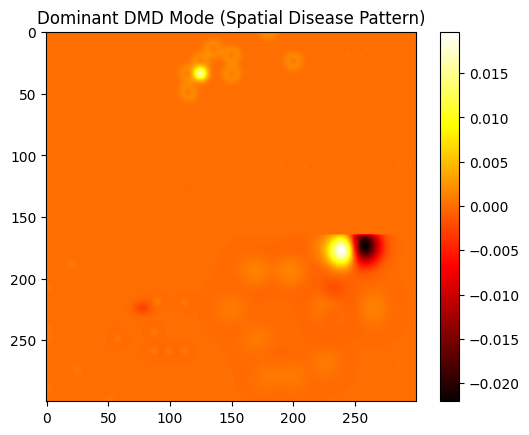

In [33]:
import matplotlib.pyplot as plt
plt.imshow(np.real(Phi[:, 3].reshape(300, 300)), cmap='hot')
plt.colorbar()
plt.title("Dominant DMD Mode (Spatial Disease Pattern)")
plt.show()

9. Reconstruction

[ 6274.534    +0.j     9356.204+29631.826j  9356.204-29631.826j
 17470.078    +0.j   ]
[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


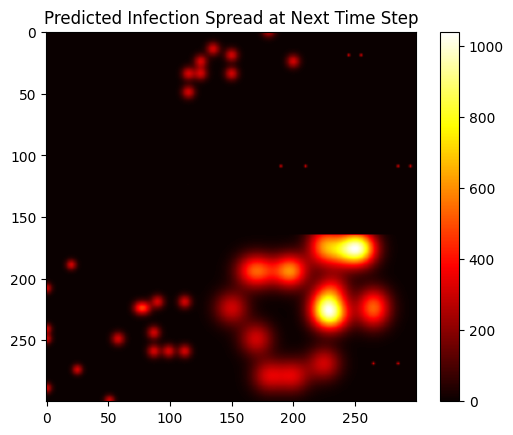

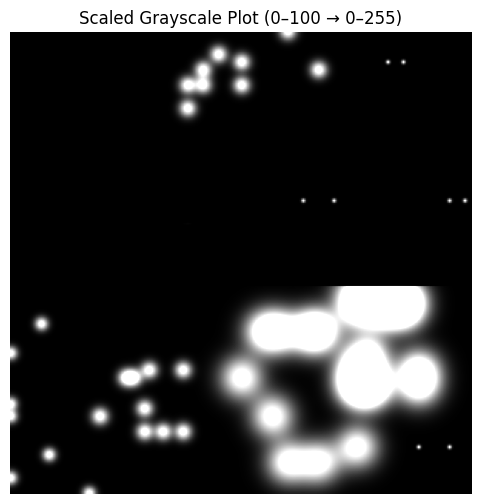

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


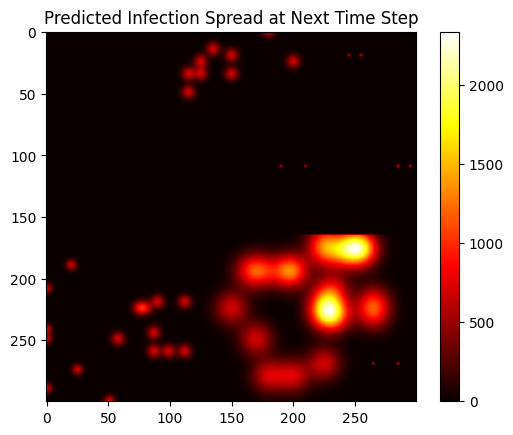

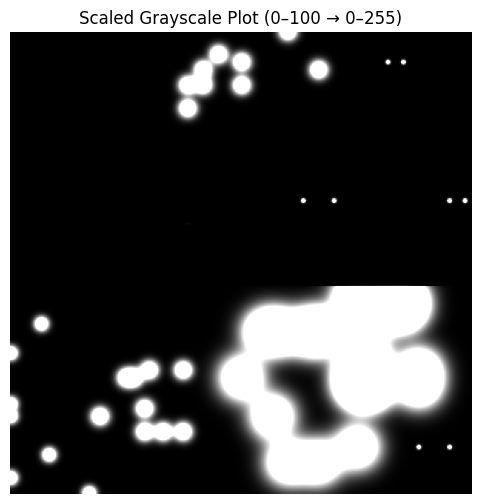

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


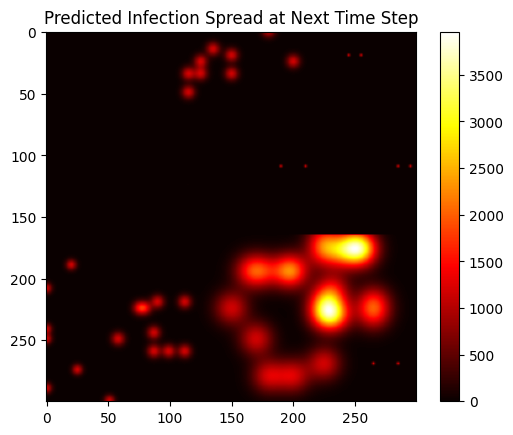

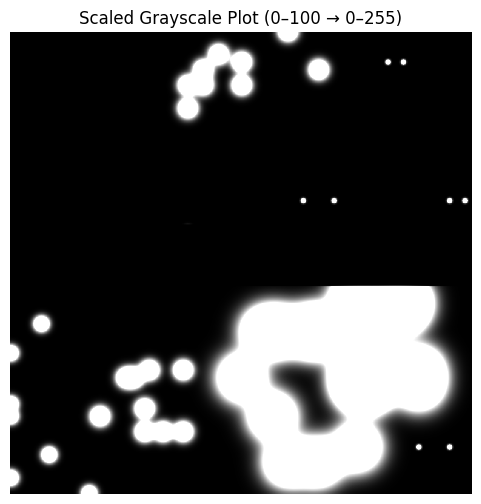

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


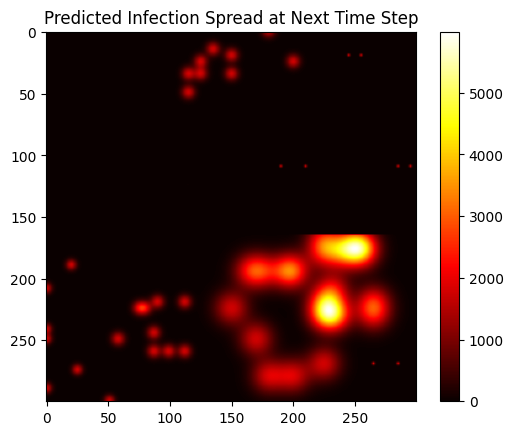

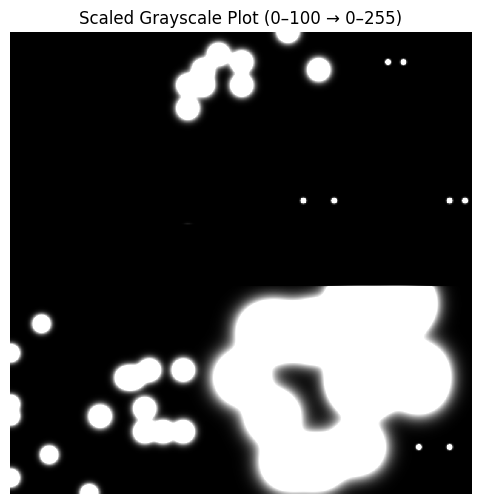

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


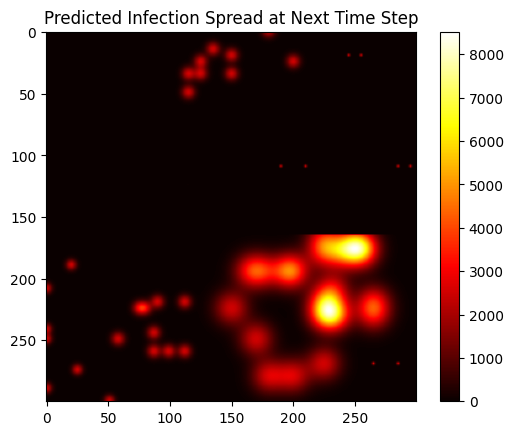

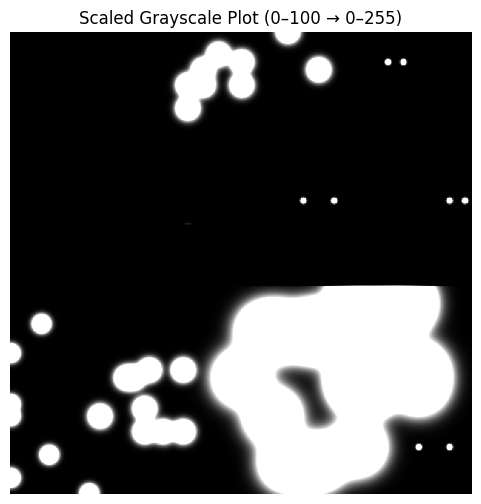

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


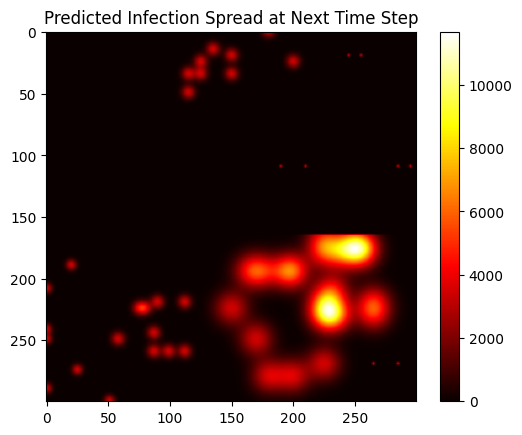

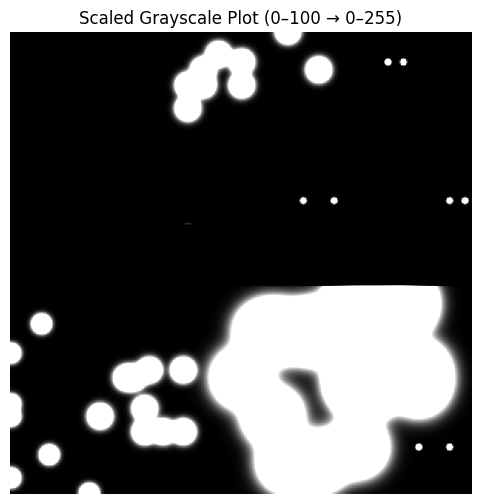

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


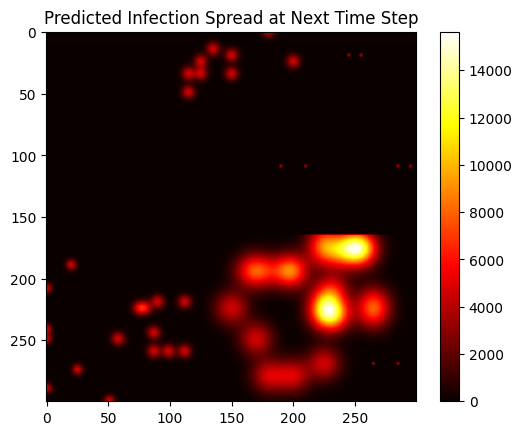

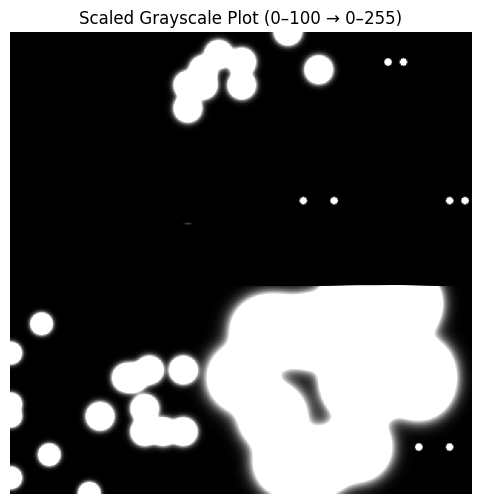

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


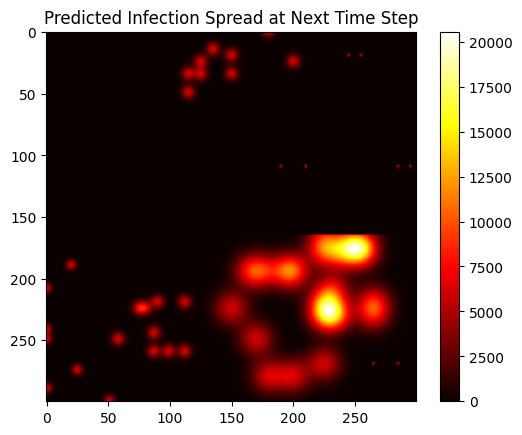

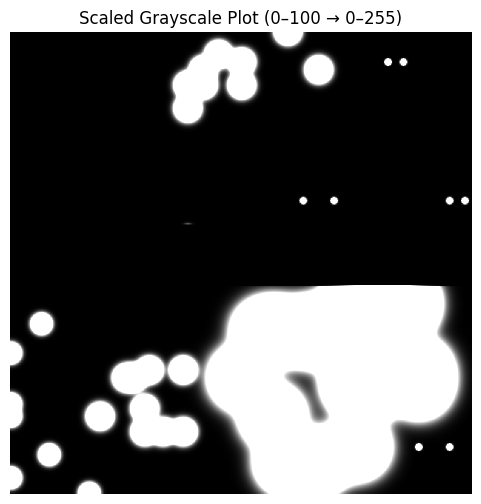

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


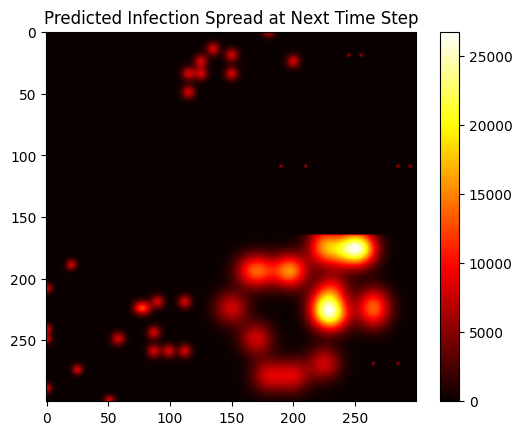

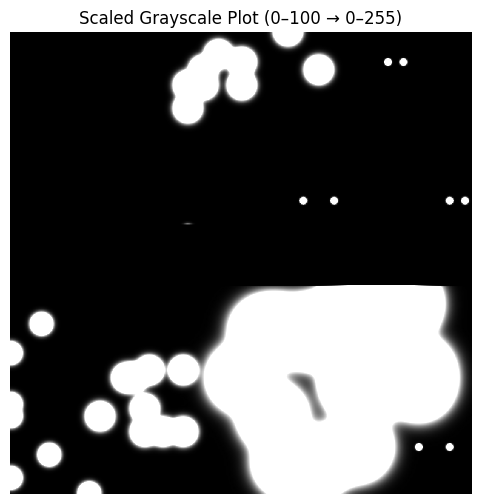

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


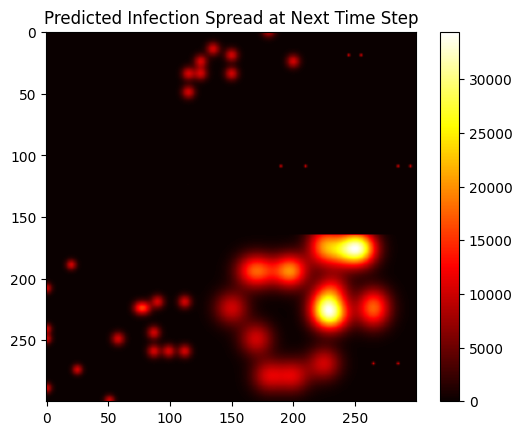

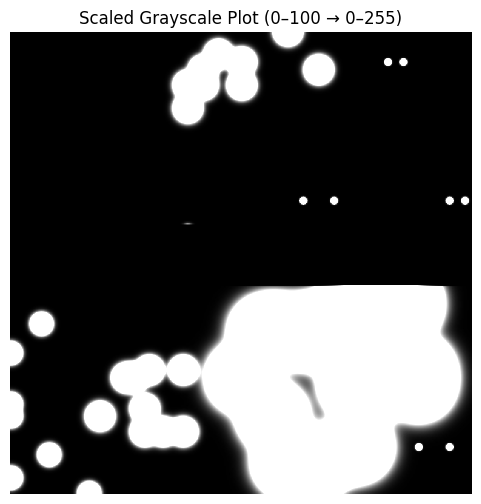

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


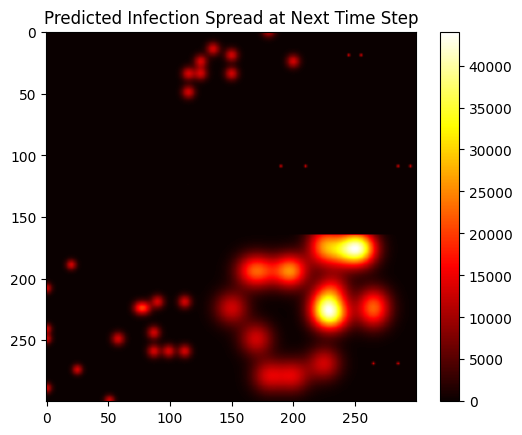

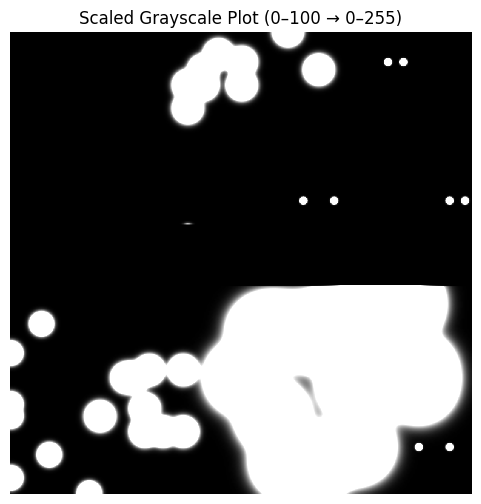

[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 ...
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
(90000, 1)


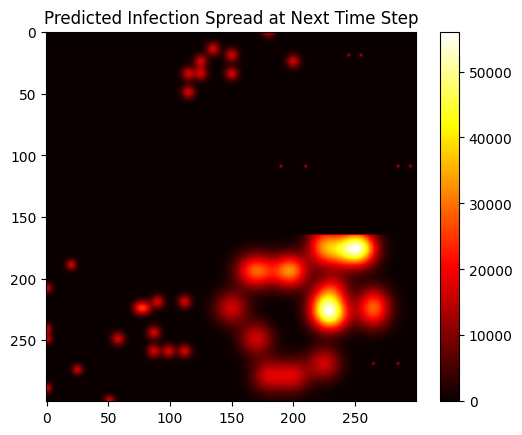

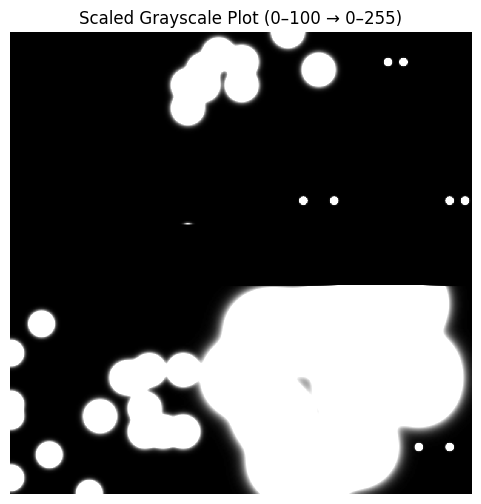

In [64]:
import numpy as np

x1_vec = X1[:, 0]
b = np.linalg.pinv(Phi) @ x1_vec
print(b)

X = np.zeros((90000, 1))
for time_stamp in range(40,100,5):
    for i in range(len(b)):
        X = X + b[i] * Phi[:,i].reshape(90000,1) * np.exp(np.log(eigenvalues[i]) * time_stamp)
    print(X)
    print(X.shape)
    X_reshaped = X.reshape(300, 300)
    plt.imshow(np.real(X_reshaped), cmap='hot')
    plt.colorbar()
    plt.title("Predicted Infection Spread at Next Time Step")
    plt.show()

    plt.figure(figsize=(6,6))
    plt.imshow(np.real(X_reshaped), cmap='gray', vmin=0, vmax=255)
    plt.title("Scaled Grayscale Plot (0–100 → 0–255)")
    plt.axis('off')
    plt.show()
